In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

In [5]:
def compute_autocorrelation(data, t_lim):
    tmax = len(data)
    autocorr = np.empty(t_lim)
    
    avg_tot_2 = np.sum(data * data) / tmax
    avg_tot = np.sum(data) / tmax
    var_tot = avg_tot_2 - np.power(avg_tot, 2)
    
    for t in range(t_lim):
        dt = tmax - t
        num = np.sum(data[:dt]*data[t:])/dt - np.sum(data[:dt])*np.sum(data[t:])/(dt*dt)
        autocorr[t] = num / var_tot
    
    return autocorr
        
        

In [8]:
steps, energy = np.loadtxt("../OUTPUT-2/potential_energy.dat", usecols=(0,1), unpack=True)

tmax = 1000
autocorrelation = compute_autocorrelation(energy, tmax)

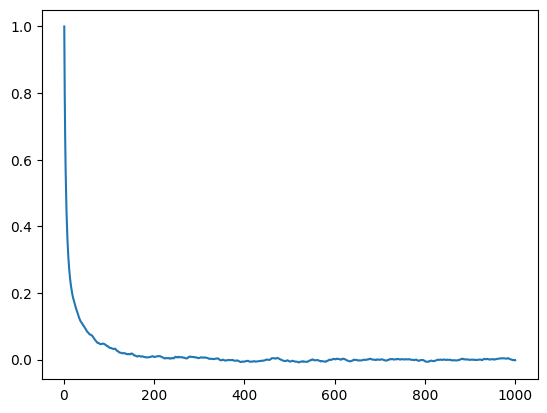

In [9]:
plt.plot(steps[:tmax], autocorrelation)

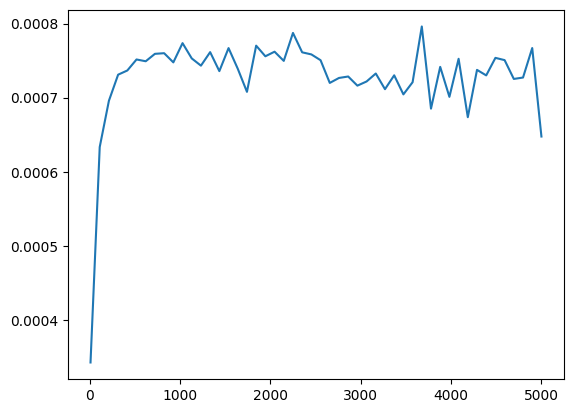

In [10]:
L = np.linspace(10,5000)
#L = [10, 20, 40, 50, 80, 100, 200, 400, 500, 800, 1000, 5000]

def error(L, data):
    N = int(len(data)//L)
    """ averages = np.zeros(N)
    for i in range(N):
        averages[i] = np.sum(data[i*L:(i+1)*L]) """
    averages = np.array([np.sum(data[i*L:(i+1)*L]) / L for i in range(N)])
    sum_averages = np.sum(averages) / N
    sum_averages2 = np.sum(averages * averages) / N
    return math.sqrt((sum_averages2-np.power(sum_averages,2))/(N-1))

errors = [error(int(l), energy) for l in L]

plt.plot(L, errors);

## Esercizio 07.4

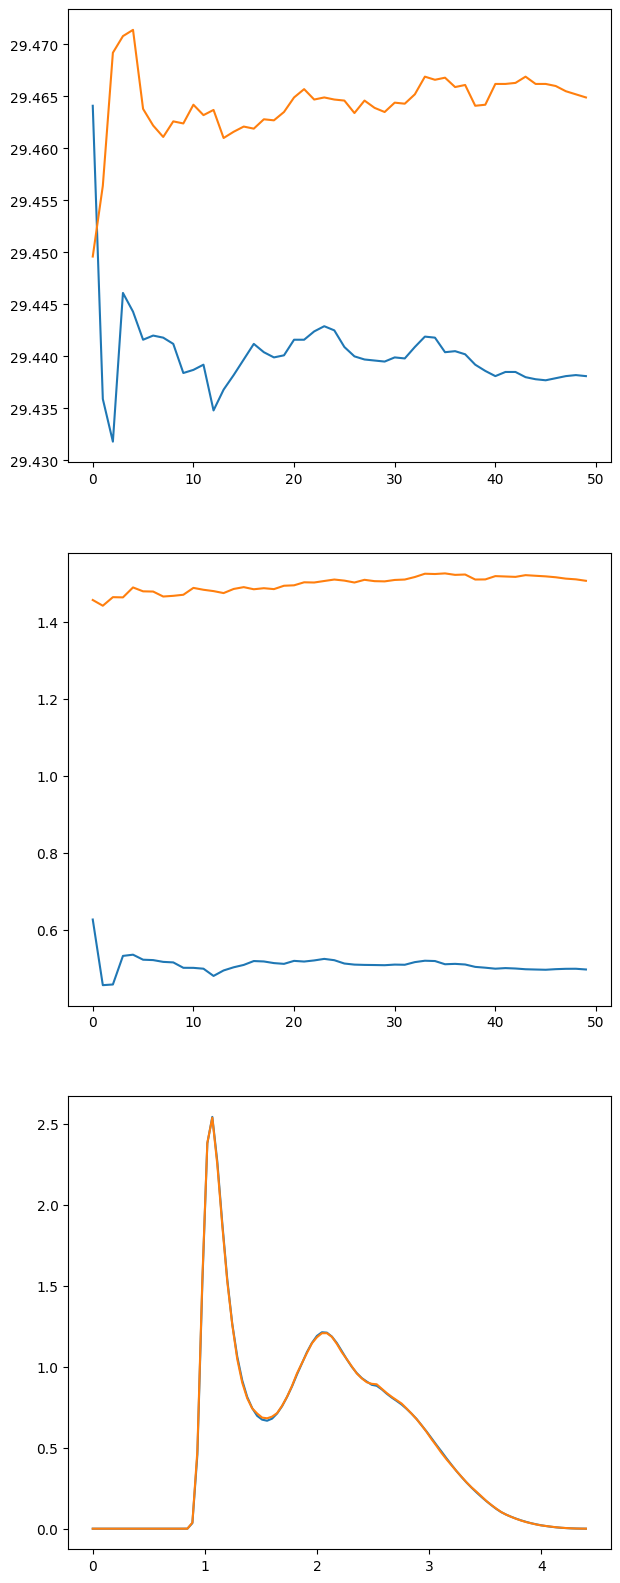

In [16]:
energy_MC = np.loadtxt("../OUTPUT-4/potential_energy.dat", usecols=(2,3))
pressure_MC = np.loadtxt("../OUTPUT-4/pressure.dat", usecols=(2,3))
data_gofr_MC = np.loadtxt("../OUTPUT-4/gofr.dat")
r, gofr_MC = data_gofr_MC[:,0], data_gofr_MC[:,1:]
blocks = np.arange(len(energy_MC))

energy_DM = np.loadtxt("../OUTPUT-5/potential_energy.dat", usecols=(2,3))
pressure_DM = np.loadtxt("../OUTPUT-5/pressure.dat", usecols=(2,3))
gofr_DM = np.loadtxt("../OUTPUT-5/gofr.dat", usecols=(1,2))

fig, axs = plt.subplots(3, 1, figsize=(7,20))

axs[0].plot(blocks, energy_MC[:,0])
axs[0].plot(blocks, energy_DM[:,0])

axs[1].plot(blocks, pressure_MC[:,0])
axs[1].plot(blocks, pressure_DM[:,0])

axs[2].plot(r, gofr_MC[:,0])
axs[2].plot(r, gofr_DM[:,0])